# First-order scattering: roughness, dielectric fluctuations and their correlation

Visualisation of the results of *Non-additive surface and volume backscattering from a rough
interface over a correlated random medium* (Franco & Calzetta) — the EM scattering model built
on the coordinate change $z=\zeta+h(\mathbf{x})f(\zeta)$.

In each channel the incoherent backscattered power has **three contributions**:

$$\frac{1}{\mathcal{A}}\langle|\chi^{(1)}|^2\rangle
= \underbrace{I_{\rm rough}}_{\propto\,W_h}
+ \underbrace{I_{\rm diel}}_{\propto\,W_\varepsilon}
+ \underbrace{I_{\rm cross}}_{\propto\,\rho_0\,W_{h\varepsilon}}$$

The third term is the central result of the paper: if the roughness and the dielectric
fluctuations are correlated ($\rho_0\neq0$), a **new scattering mechanism appears already at
first order**, and the two random characteristics of the target **stop being additive**.

This notebook quantifies when that term matters.

---

### Formulae implemented

**VV channel** (eq. 5.11 of the manuscript), with the exact geometric amplitude

$$I_{VV}=\frac{4R_V}{T_V}k^2+\frac{2\epsilon_1(\epsilon_1-1)k^4}{K_1^2}T_V$$

$$\frac{\langle|\psi^{(1)}|^2\rangle}{\mathcal{A}}
=|I_{VV}|^2W_h
+\frac{|\epsilon_1|^2k_i^4k^4|T_V|^2}{|K_1|^4}\,\Omega_\varepsilon
+2\,\Re\!\left\{I_{VV}\frac{\epsilon_1^*k_i^2k^2T_V^*}{(K_1^*)^2}\,\Omega_{h\varepsilon}\right\}$$

**HH channel** (eq. 5.3)

$$\frac{\langle|\varphi^{(1)}|^2\rangle}{\mathcal{A}}
=8K^3_0|R_H|^2W_h
+\frac{k_i^4|T_H|^4}{4 K_0 K_1''}\,\Omega_\varepsilon
-2\,\Re\!\left\{2k_i^2K_0R_H(T_H^*)^2\,\Omega_{h\varepsilon}\right\}$$

with $\Omega_\varepsilon=\frac{s_\varepsilon^2l_r^2}{4\pi}e^{-(kl_r)^2}\frac{l_v}{1+2K_1'l_v}$,
$\Omega_{h\varepsilon}=\rho_0\frac{s_\varepsilon s L_r^2}{4\pi}e^{-(kL_r)^2}\frac{L_v}{1+2L_v(K_1''+\imath K_1')}$,
and $W_h=\frac{s^2l^2}{4\pi}e^{-(kl)^2}$.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# --------------------------------------------------------------- palette
# Categorical: slots 1-3 (blue, orange, aqua) — all-pairs checked for CVD.
SER = ["#2a78d6", "#eb6834", "#1baf7a"]
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8983"
SURF, GRID = "#fcfcfb", "#e6e5e1"

# Sequential: single hue (blue), light -> dark.
SEQ = LinearSegmentedColormap.from_list("seq_blue", [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
# Diverging: blue <-> red with a neutral grey midpoint.
DIV = LinearSegmentedColormap.from_list("div_br", [
    "#0d366b", "#256abf", "#6da7ec", "#cde2fb", "#f0efec",
    "#f7b9b8", "#e87675", "#d13a39", "#8b1f1f"])

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK3, "ytick.color": INK3, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.grid": False,
    "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK2,
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round",
    "font.size": 10, "figure.dpi": 120,
})
print("ready")

ready


## 1 · Model

In [2]:
LAM = 1.0                 # lambda: incident wavelength  (all length in lambda units)
Ki  = 2*np.pi/LAM

def fresnel(theta, eps1, ki=Ki):
    '''Returns k, K0, K1, R_V, T_V, R_H, T_H. theta in radians. Branch Im(K1)>0.'''
    theta = np.asarray(theta, dtype=float)
    eps1  = np.asarray(eps1, dtype=complex)
    k = ki*np.sin(theta)
    K0 = ki*np.cos(theta)
    K1 = np.sqrt(eps1*ki**2 - k**2 + 0j)
    K1 = np.where(K1.imag < 0, -K1, K1)        # K_1'' > 0
    RV = (eps1*K0 - K1)/(eps1*K0 + K1);  TV = 1 - RV
    RH = (K0 - K1)/(K0 + K1);            TH = 1 + RH
    return k, K0, K1, RV, TV, RH, TH

def I_VV_amp(theta, eps1, ki=Ki):
    '''Exact geometric amplitude of the VV channel (eq. A.41).'''
    k, K0, K1, RV, TV, _, _ = fresnel(theta, eps1, ki)
    return 4*RV/TV*k**2 + 2*eps1*(eps1-1)*k**4/K1**2*TV

# Defaults: moist soil at L band, roughness inside the SPM regime (ki*s << 1).
# s and s_eps are chosen so that the two mechanisms are *balanced* (see §4): the cross
# term is a geometric mean, hence largest when I_rough ~ I_diel.
P0 = dict(eps1=15+3j, s=0.015, l=0.5, seps=4.0, lr=0.5, lv=0.20,
          rho0=0.5,  Lr=0.5, Lv=0.03)

def contributions(theta, ki=Ki, **kw):
    '''Returns a dict with the three contributions of each channel.
    Each entry is an array with the broadcast shape of theta and the parameters.'''
    p = {**P0, **kw}
    eps1 = np.asarray(p["eps1"], dtype=complex)
    s, l, seps, lr, lv = p["s"], p["l"], p["seps"], p["lr"], p["lv"]
    rho0, Lr, Lv = p["rho0"], p["Lr"], p["Lv"]

    k, K0, K1, RV, TV, RH, TH = fresnel(theta, eps1, ki)
    K1p, K1pp = K1.real, K1.imag
    IVV = 4*RV/TV*k**2 + 2*eps1*(eps1-1)*k**4/K1**2*TV

    Wh   = s**2*l**2/(4*np.pi)*np.exp(-(k*l)**2)
    Om_e = seps**2*lr**2/(4*np.pi)*np.exp(-(k*lr)**2) * lv/(1+2*K1p*lv)
    Om_he= rho0*seps*s*Lr**2/(4*np.pi)*np.exp(-(k*Lr)**2) * Lv/(1+2*Lv*(K1pp+1j*K1p))

    hh_r = 8*K0**3*np.abs(RH)**2 * Wh
    hh_d = ki**4*np.abs(TH)**4/(4*K0*K1pp) * Om_e
    hh_c = -2*np.real(2*ki**2*K0*RH*np.conj(TH)**2 * Om_he)

    vv_r = np.abs(IVV)**2 * Wh
    vv_d = np.abs(eps1)**2*ki**4*k**4*np.abs(TV)**2/np.abs(K1)**4 * Om_e/(2*K1pp)
    vv_c = 2*np.real(IVV*np.conj(eps1)*ki**2*k**2*np.conj(TV)/np.conj(K1)**2 * Om_he)

    return dict(HH=(hh_r, hh_d, hh_c), VV=(vv_r, vv_d, vv_c),
                K0=K0, k=k, K1=K1, TV=TV, IVV=IVV)

def eta(theta, canal="VV", **kw):
    '''Fractional departure from additivity: I_cross / (I_rough + I_diel).'''
    r, d, c = contributions(theta, **kw)[canal]
    return c/(r+d)
print("ready")

ready


## 2 · Validation: the VV channel reproduces the SPM

Numerical check of the closure proved in the manuscript:
$\widehat{E}^{(1)}_{VV}=-E^{(1)}_{VV}\big|_{\rm SPM}$ **exactly**, for every angle and every
$\epsilon_1$. The residual should be zero to machine precision.

In [3]:
th = np.radians(np.linspace(1, 89, 400))
for e in [4+0j, 15+3j, 30+10j, 2.5+0.1j]:
    k, K0, K1, RV, TV, _, _ = fresnel(th, e)
    EVV_hat = -(K0*TV/(2*k**2)) * I_VV_amp(th, e)            # unit incident amplitude
    EVV_spm = 2*K0*(e-1)/(e*K0+K1)**2 * (K1**2 + e*k**2)      # SPM kernel
    res = np.max(np.abs(EVV_hat/EVV_spm + 1))
    print(f"  eps1 = {e!s:>12}   max |Ehat/SPM + 1| = {res:.2e}")

  eps1 =       (4+0j)   max |Ehat/SPM + 1| = 8.88e-16
  eps1 =      (15+3j)   max |Ehat/SPM + 1| = 8.92e-16
  eps1 =     (30+10j)   max |Ehat/SPM + 1| = 1.34e-15
  eps1 =   (2.5+0.1j)   max |Ehat/SPM + 1| = 1.00e-15


## 3 · Where each contribution lives

The three contributions against incidence angle. The cross term is $2\Re\{\cdots\}$:
**it has a sign**, and can either enhance or suppress the backscatter. Its absolute value is
plotted, with the sign indicated.

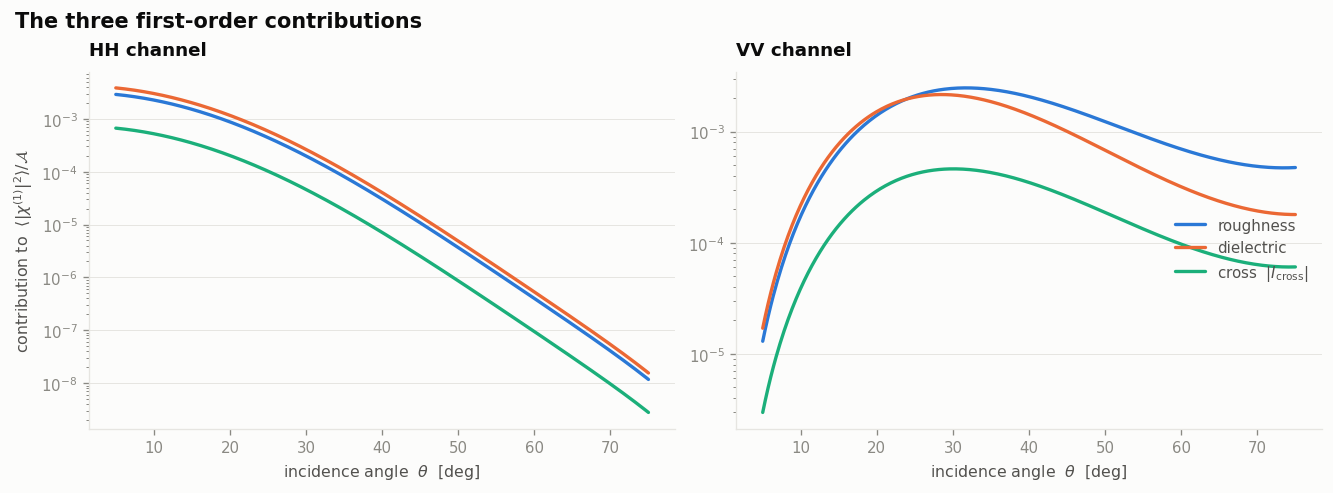

In [4]:
th_d = np.linspace(5, 75, 400); th = np.radians(th_d)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True)
for ax, ch in zip(axes, ["HH", "VV"]):
    r, d, c = contributions(th)[ch]
    ax.semilogy(th_d, r, color=SER[0], label="roughness")
    ax.semilogy(th_d, d, color=SER[1], label="dielectric")
    ax.semilogy(th_d, np.abs(c), color=SER[2], label="cross  $|I_{\\rm cross}|$")
    # mark the sign of the cross term
    neg = c < 0
    if neg.any():
        ax.semilogy(th_d[neg], np.abs(c[neg]), color=SER[2], ls=":", lw=2.6)
    ax.set_title(f"{ch} channel")
    ax.set_xlabel("incidence angle  $\\theta$  [deg]")
    ax.grid(True, which="major", axis="y")
    ax.set_axisbelow(True)
axes[0].set_ylabel("contribution to  $\\langle|\\chi^{(1)}|^2\\rangle/\\mathcal{A}$")
axes[1].legend(loc="center right")
if any((contributions(th)[c][2] < 0).any() for c in ("HH", "VV")):
    axes[1].text(0.02, 0.06, "dotted line: cross term negative",
                 transform=axes[1].transAxes, color=INK3, fontsize=8.5)
fig.suptitle("The three first-order contributions", x=0.006, ha="left",
             fontsize=12.5, fontweight="semibold", color=INK)
plt.show()

## 4 · The central map: departure from additivity

$$\eta \;\equiv\; \frac{I_{\rm cross}}{I_{\rm rough}+I_{\rm diel}}$$

is the relative error committed by assuming that roughness and dielectric **simply add**.
$\eta=0$ is exact additivity; $\eta>0$ enhancement, $\eta<0$ suppression. Diverging scale
centred on zero, with contours at $\pm5\%$, $\pm10\%$ and $\pm20\%$.

Structurally, $I_{\rm cross}$ is a **geometric mean** of the other two
($\propto s_\varepsilon s$, against $s^2$ and $s_\varepsilon^2$), so that it is largest when
the two mechanisms are **balanced** and is buried whenever either dominates: an imbalance of two
orders of magnitude between $I_{\rm rough}$ and $I_{\rm diel}$ costs roughly an order of
magnitude in $\eta$, however large $\rho_0$ may be. The default parameters sit at the balance
point.

(The naive bound $|\eta|\le|\rho_0|$ does **not** hold here as an inequality, because the three
correlation functions carry different scales and the cross term is a real part; at the default
parameters it would give $0.49$ against an actual $0.093$. It is quoted as a scaling, not a
theorem.)

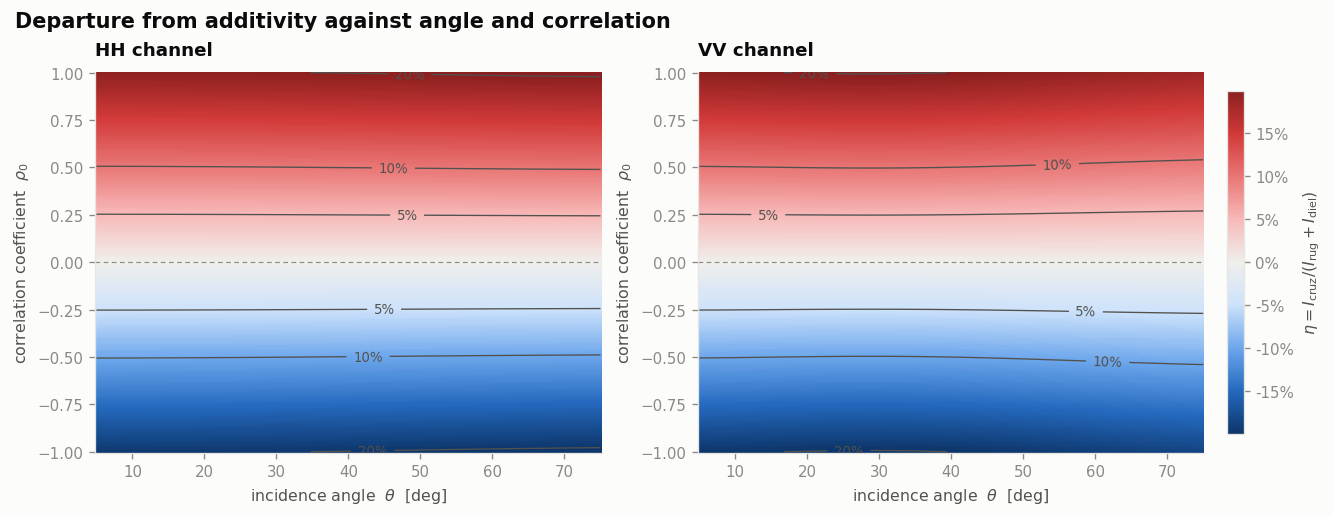

In [5]:
def heatmap(ax, X, Y, Z, xlabel, ylabel, title, levels=(0.05, 0.10, 0.20),
            vmax=None, diverging=True):
    '''Diverging only if the data change sign; otherwise single-hue sequential.'''
    vmax = vmax or np.nanpercentile(np.abs(Z), 99.5)
    if diverging and (Z.min() < 0 < Z.max()):
        im = ax.pcolormesh(X, Y, Z, cmap=DIV, norm=TwoSlopeNorm(0, -vmax, vmax),
                           shading="auto", rasterized=True)
        lc = INK2
    else:
        flip = Z.max() <= 0
        im = ax.pcolormesh(X, Y, -Z if flip else Z, cmap=SEQ, vmin=0, vmax=vmax,
                           shading="auto", rasterized=True)
        lc = "#ffffff"
    cs = ax.contour(X, Y, np.abs(Z), levels=levels, colors=[lc], linewidths=0.8)
    ax.clabel(cs, fmt=lambda v: f"{v:.0%}", fontsize=8, colors=[INK2])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    return im

th_d = np.linspace(5, 75, 220); rho = np.linspace(-1, 1, 220)
TH, RHO = np.meshgrid(th_d, rho)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, ch in zip(axes, ["HH", "VV"]):
    Z = eta(np.radians(TH), ch, rho0=RHO)
    im = heatmap(ax, TH, RHO, Z, "incidence angle  $\\theta$  [deg]",
                 "correlation coefficient  $\\rho_0$", f"{ch} channel")
    ax.axhline(0, color=INK3, lw=0.7, ls=(0, (4, 3)))
fig.colorbar(im, ax=axes, label="$\\eta = I_{\\rm cruz}/(I_{\\rm rug}+I_{\\rm diel})$",
             shrink=0.9, pad=0.02, format=lambda v, _: f"{v:.0%}")
fig.suptitle("Departure from additivity against angle and correlation", x=0.006,
             ha="left", fontsize=12.5, fontweight="semibold", color=INK)
plt.show()

### The two physical conditions

**Loss.** $\epsilon_1''$ fixes $K_1''$, which controls how deep the wave sees the medium. The
dielectric term integrates the whole illuminated volume ($\propto1/K_1''$), whereas the cross
term only weighs the layer $|\zeta|\lesssim L_v$ adjacent to the interface. As the loss grows
the volume term is extinguished and the near-surface coupling is left exposed.

**Correlation depth.** $\Omega_{h\varepsilon}\propto L_v/[1+2L_v(K_1''+\imath K_1')]$ has a
**ridge**: if $L_v$ is very small there is not enough correlated volume; if it is very large, the
phase $2L_vK_1'$ rotates across the layer and the deep contributions cancel against each other.
Careful: as $L_v$ grows the effect **does not fall to zero but to a plateau** — the modulus of
$\Omega_{h\varepsilon}$ saturates at $1/(2|K_1|)$, because the layer within one coherence length
of the interface always contributes. The ridge sits at $2L_v|K_1|\sim1$ (numerically between
$1.1$ and $1.5$ for $\epsilon_1''/\epsilon_1'\lesssim0.2$) and its height above the plateau
depends on the loss: a factor of $5$ for $\epsilon_1''=1$, a factor of $2$ for
$\epsilon_1''=3$, and it washes out by $\epsilon_1''=10$, when the wave is absorbed before the
phase can rotate. This is a concrete prediction of where to look for the effect.

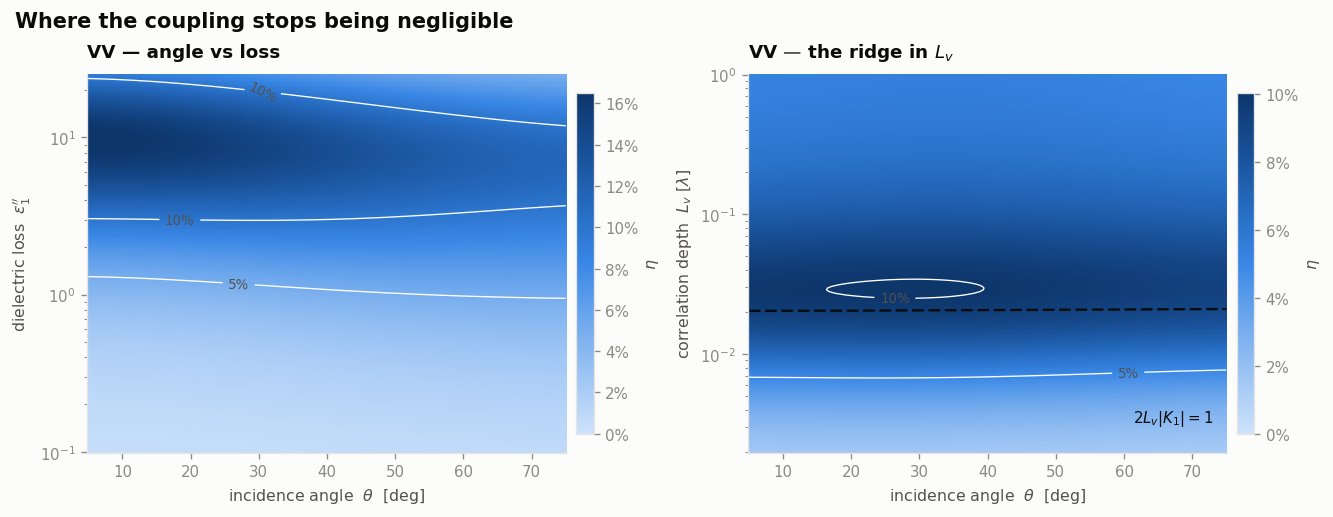

In [6]:
th_d = np.linspace(5, 75, 220)
epp  = np.logspace(-1, 1.4, 220)          # eps1'' from 0.1 to ~25
Lvv  = np.logspace(-2.7, 0.0, 220)        # L_v from 0.002 to 1 lambda

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

TH, EPP = np.meshgrid(th_d, epp)
Z1 = eta(np.radians(TH), "VV", eps1=15+1j*EPP)
im = heatmap(axes[0], TH, EPP, Z1, "incidence angle  $\\theta$  [deg]",
             "dielectric loss  $\\epsilon_1''$", "VV — angle vs loss")
axes[0].set_yscale("log")

TH2, LV = np.meshgrid(th_d, Lvv)
Z2 = eta(np.radians(TH2), "VV", Lv=LV)
im2 = heatmap(axes[1], TH2, LV, Z2, "incidence angle  $\\theta$  [deg]",
              "correlation depth  $L_v\\ [\\lambda]$",
              "VV — the ridge in $L_v$")
axes[1].set_yscale("log")
# the coherence condition 2 L_v |K_1| = 1
_, _, K1_, _, _, _, _ = fresnel(np.radians(th_d), 15+3j)
axes[1].plot(th_d, 1/(2*np.abs(K1_)), color=INK, lw=1.4, ls=(0, (5, 2)))
axes[1].text(0.97, 0.08, "$2L_v|K_1| = 1$", transform=axes[1].transAxes,
             ha="right", color=INK, fontsize=9)

fig.colorbar(im, ax=axes[0], label="$\\eta$", shrink=0.9, pad=0.02,
             format=lambda v, _: f"{v:.0%}")
fig.colorbar(im2, ax=axes[1], label="$\\eta$", shrink=0.9, pad=0.02,
             format=lambda v, _: f"{v:.0%}")
fig.suptitle("Where the coupling stops being negligible", x=0.006, ha="left",
             fontsize=12.5, fontweight="semibold", color=INK)
plt.show()

## 5 · Proposed result: the retrieval bias

$\eta$ is not directly measurable — it would require knowing the three contributions separately.
What does have a practical consequence is **the error committed when the data are inverted with
an additive model**. If the amplitude of the dielectric fluctuations is fitted assuming
$\rho_0=0$, the whole of the cross term is absorbed into $s_\varepsilon$, and since
$I_{\rm diel}\propto s_\varepsilon^2$,

$$\frac{s_\varepsilon^{\rm eff}}{s_\varepsilon}=\sqrt{1+\frac{I_{\rm cross}}{I_{\rm diel}}}$$

The denominator is $I_{\rm diel}$ **alone**, not $I_{\rm rough}+I_{\rm diel}$: that is why the
bias is substantially larger than $\eta$, and why it **grows when the dielectric term is weak**
— precisely the regime in which one would want to measure it.

> **A negative result, also useful.** We first tried the polarization ratio
> $\sigma^0_{VV}/\sigma^0_{HH}$ as an observable. It does not work: the coupling displaces both
> channels by a similar amount and the effect cancels in the quotient (below $0.10$ dB over the
> whole domain, an order of magnitude below typical calibration accuracy). Worth knowing before
> designing a campaign.

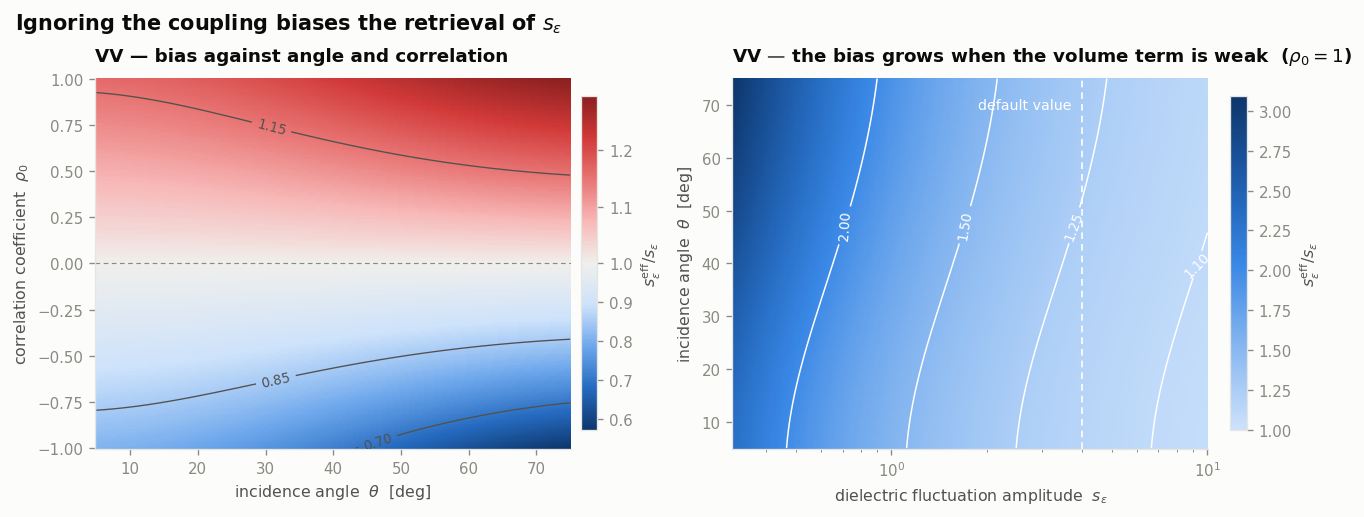

In [7]:
def bias(theta, canal="VV", **kw):
    # Bias factor  s_eps_eff / s_eps  when inverting with an additive model.
    _, d, c = contributions(theta, **kw)[canal]
    return np.sqrt(np.maximum(1 + c/d, 0))

th_d = np.linspace(5, 75, 220)
rho  = np.linspace(-1, 1, 220)
se   = np.logspace(-0.5, 1.0, 220)        # s_eps from ~0.3 to 10

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

TH, RHO = np.meshgrid(th_d, rho)
B1 = bias(np.radians(TH), "VV", rho0=RHO)
# ratio: diverging, centred on 1, with the actual data limits
im = axes[0].pcolormesh(TH, RHO, B1, cmap=DIV,
                        norm=TwoSlopeNorm(1, B1.min(), B1.max()),
                        shading="auto", rasterized=True)
cs = axes[0].contour(TH, RHO, B1, levels=[0.7, 0.85, 1.15, 1.3], colors=[INK2], linewidths=0.8)
axes[0].clabel(cs, fmt=lambda x: f"{x:.2f}", fontsize=8, colors=[INK2])
axes[0].axhline(0, color=INK3, lw=0.7, ls=(0, (4, 3)))
axes[0].set_xlabel("incidence angle  $\\theta$  [deg]")
axes[0].set_ylabel("correlation coefficient  $\\rho_0$")
axes[0].set_title("VV — bias against angle and correlation")
fig.colorbar(im, ax=axes[0], label="$s_\\varepsilon^{\\rm eff}/s_\\varepsilon$",
             shrink=0.9, pad=0.02)

SE, TH2 = np.meshgrid(se, th_d)
B2 = bias(np.radians(TH2), "VV", seps=SE, rho0=1.0)
# here rho0=+1, so the bias is always >= 1: single-hue sequential scale
im2 = axes[1].pcolormesh(SE, TH2, B2, cmap=SEQ, vmin=1, vmax=np.nanmax(B2),
                         shading="auto", rasterized=True)
cs2 = axes[1].contour(SE, TH2, B2, levels=[1.1, 1.25, 1.5, 2.0], colors=["#ffffff"],
                      linewidths=0.9)
axes[1].clabel(cs2, fmt=lambda x: f"{x:.2f}", fontsize=8, colors=["#ffffff"])
axes[1].set_xscale("log")
axes[1].axvline(P0["seps"], color="#ffffff", lw=1.0, ls=(0, (4, 3)))
axes[1].annotate("default value", xy=(P0["seps"], 70), xytext=(-6, 0),
                 textcoords="offset points", ha="right", va="center",
                 color="#ffffff", fontsize=8.5)
axes[1].set_xlabel("dielectric fluctuation amplitude  $s_\\varepsilon$")
axes[1].set_ylabel("incidence angle  $\\theta$  [deg]")
axes[1].set_title("VV — the bias grows when the volume term is weak  ($\\rho_0=1$)")
fig.colorbar(im2, ax=axes[1], label="$s_\\varepsilon^{\\rm eff}/s_\\varepsilon$",
             shrink=0.9, pad=0.02)

fig.suptitle("Ignoring the coupling biases the retrieval of $s_\\varepsilon$", x=0.006,
             ha="left", fontsize=12.5, fontweight="semibold", color=INK)
plt.show()

## 6 · Why the coupling is hard to see

Fractional composition of the power against angle. Roughness and dielectric **do** have clearly
distinct angular signatures — in VV they cross near $24^\circ$ — so that an angular sweep
separates those two mechanisms without ambiguity.

The cross term, by contrast, is **nearly flat**: it contributes a practically constant fraction
of the power across the whole range. That is the underlying reason why it goes unnoticed: it
leaves no shape anomaly to betray it, it simply rescales the level. And because it rescales, it
is absorbed into the fitted parameters — which is exactly the bias of the previous section.

> Put differently: the coupling is not detected by looking at the shape of $\sigma^0(\theta)$.
> An independent constraint on $s_\varepsilon$ (for instance *in situ* sampling, or a second
> frequency) is needed to expose it.

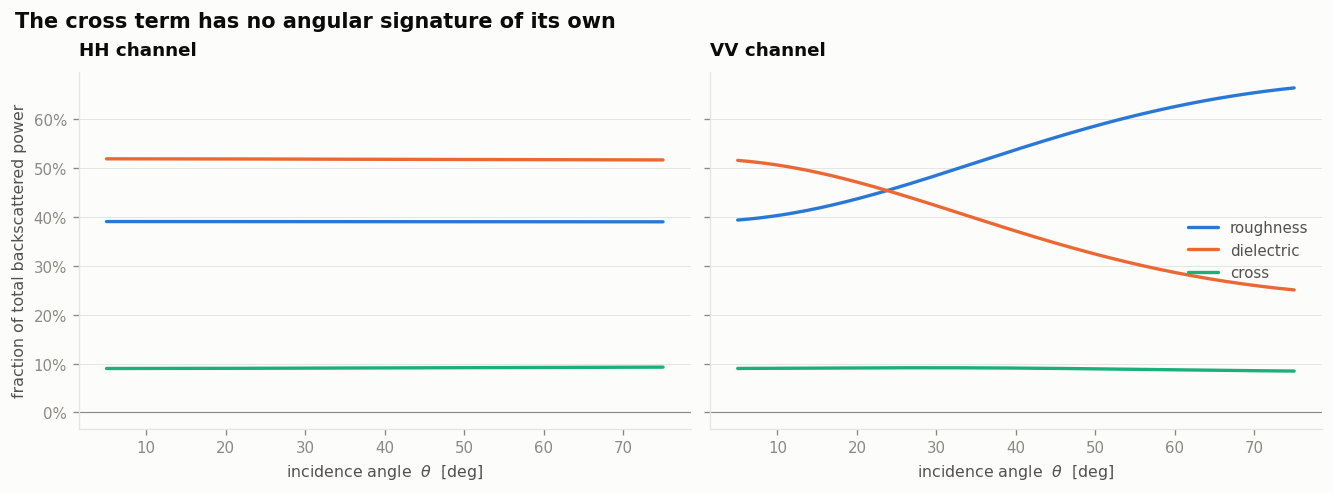

In [8]:
th_d = np.linspace(5, 75, 400); th = np.radians(th_d)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True, sharey=True)
for ax, ch in zip(axes, ["HH", "VV"]):
    r, d, c = contributions(th)[ch]
    tot = r + d + c
    ax.plot(th_d, r/tot, color=SER[0], label="roughness")
    ax.plot(th_d, d/tot, color=SER[1], label="dielectric")
    ax.plot(th_d, c/tot, color=SER[2], label="cross")
    ax.axhline(0, color=INK3, lw=0.7)
    ax.set_xlabel("incidence angle  $\\theta$  [deg]"); ax.set_title(f"{ch} channel")
    ax.grid(True, axis="y"); ax.set_axisbelow(True)
axes[0].set_ylabel("fraction of total backscattered power")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
axes[1].legend(loc="center right")
fig.suptitle("The cross term has no angular signature of its own", x=0.006, ha="left",
             fontsize=12.5, fontweight="semibold", color=INK)
plt.show()

## 7 · The recovered term in $I_{VV}$

The exact geometric amplitude has two pieces,

$$I_{VV}=\underbrace{\frac{4R_V}{T_V}k^2}_{\rm (a)}
+\underbrace{\frac{2\epsilon_1(\epsilon_1-1)k^4}{K_1^2}T_V}_{\rm (b)}$$

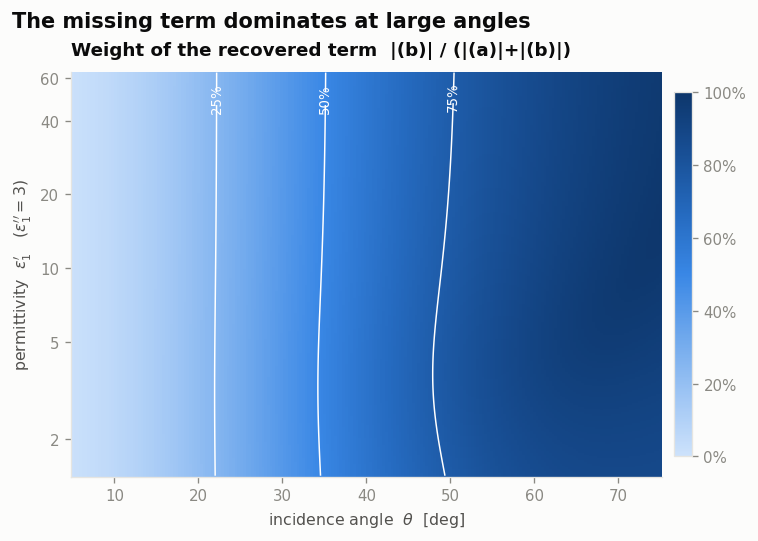

In [9]:
th_d = np.linspace(5, 75, 220); epr = np.logspace(0.15, 1.8, 220)   # eps1' from ~1.4 to ~63
TH, EPR = np.meshgrid(th_d, epr)
e = EPR + 3j
k, K0, K1, RV, TV, _, _ = fresnel(np.radians(TH), e)
a = 4*RV/TV*k**2
b = 2*e*(e-1)*k**4/K1**2*TV
W = np.abs(b)/(np.abs(a)+np.abs(b))

fig, ax = plt.subplots(figsize=(6.2, 4.4), constrained_layout=True)
im = ax.pcolormesh(TH, EPR, W, cmap=SEQ, vmin=0, vmax=1, shading="auto", rasterized=True)
cs = ax.contour(TH, EPR, W, levels=[0.25, 0.5, 0.75], colors=["#ffffff"], linewidths=0.9)
ax.clabel(cs, fmt=lambda v: f"{v:.0%}", fontsize=8, colors=["#ffffff"])
ax.set_yscale("log")
ax.set_yticks([2, 5, 10, 20, 40, 60])
ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
ax.minorticks_off()
ax.set_xlabel("incidence angle  $\\theta$  [deg]")
ax.set_ylabel("permittivity  $\\epsilon_1'$   ($\\epsilon_1''=3$)")
ax.set_title("Weight of the recovered term  |(b)| / (|(a)|+|(b)|)")
fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02, format=lambda v, _: f"{v:.0%}")
fig.suptitle("The missing term dominates at large angles", x=0.006, ha="left",
             fontsize=12.5, fontweight="semibold", color=INK)
plt.show()

---

## What these plots show

1. **The closure with the SPM is exact** (residual ~$10^{-15}$), for every angle and every
   $\epsilon_1$.

2. **The cross term has a sign.** Depending on the sign of $\rho_0$ and the phase of
   $\Omega_{h\varepsilon}$, it enhances or suppresses the backscatter. An additive model cannot
   reproduce that even qualitatively.

3. **Two conditions govern when it matters.** One of *balance* ($I_{\rm rough}\sim I_{\rm diel}$,
   because the cross term is a geometric mean) and one of *coherence* ($2L_v|K_1|\sim1$: the
   correlated layer has to be thick enough to contribute, but not so thick that the phase rotates
   within it). Outside the first the effect is buried; outside the second, on the large-$L_v$
   side, it drops to a plateau of roughly half the ridge, not to zero.

4. **It has a practical consequence**: inverting with an additive model biases the retrieved
   dielectric amplitude by $16$–$29\%$ at $\rho_0=1$, and by $55$–$92\%$ when the volume term is
   the weaker of the two — the bias is **worse** the weaker the dielectric signal. The
   polarization ratio $\sigma^0_{VV}/\sigma^0_{HH}$, by contrast, is **not** a useful
   discriminator: the coupling moves both channels alike.

5. **But an angular sweep is not enough to expose it.** Roughness and dielectric have distinct
   angular signatures and separate well; the cross term is nearly flat in $\theta$, so it leaves
   no shape anomaly — it only rescales the level, and is therefore absorbed into the fitted
   parameters. An independent constraint on $s_\varepsilon$ is needed to see it.

### Further results that could be added

- **Inversion**: given $(\sigma^0_{VV},\sigma^0_{HH})$ at several angles, can $\rho_0$ be
  recovered? A map of the Fisher matrix or of the estimation error would say whether the problem
  is well conditioned.
- **Frequency dependence**: sweeping $k_i$ with the correlation lengths fixed in physical units
  separates $l$ from $l_r$, because the factors $e^{-(kl)^2}$ and $e^{-(kl_r)^2}$ scale
  differently. This is also where the coherence condition becomes an observable.
- **Region of validity**: a contour of $k_is$ and $s/l$ where the first-order expansion still
  holds, overlaid on the maps above.
- **Real targets**: replace $\epsilon_1$ by a soil dielectric model (e.g. Dobson) and sweep
  moisture instead of an abstract $\epsilon_1$.